In [1]:
import LanusStats as ls

# Creamos el objeto que sabe hablar con Sofascore
sofa = ls.SofaScore()

# Vemos qué ligas trae LanusStats para Sofascore
ls.get_available_leagues("Sofascore")


Matplotlib is building the font cache; this may take a moment.


['Argentina Liga Profesional',
 'Argentina Copa de la Liga Profesional',
 'Argentina Primera Nacional',
 'Brasileirão Série A',
 'Bolivia Division Profesional',
 'Chile Primera Division',
 'Colombia Primera A Apertura',
 'Colombia Primera A Clausura',
 'Ecuador LigaPro',
 'Mexico LigaMX Apertura',
 'Mexico LigaMX Clausura',
 'Peru Liga 1',
 'Uruguay Primera Division',
 'Venezuela Primera Division',
 'World Cup',
 'Euros',
 'Copa America',
 'Premier League',
 'La Liga',
 'Bundesliga',
 'Serie A',
 'Ligue 1',
 'Copa Libertadores',
 'Copa Sudamericana',
 'MLS',
 'Saudi Pro League',
 'J1 League',
 'NSWL',
 'USL Championship',
 'La Liga 2',
 'Primera RFEF',
 'Champions League',
 'Europa League']

In [2]:
# Bajamos las estadísticas de temporada de todos los jugadores.
# Esto abre Chrome por detrás y pagina los resultados: puede tardar ~1 minuto.
df = sofa.scrape_league_stats(
    league="Chile Primera Division",
    season="2026"
)

print(df.shape)   # (número de jugadores, número de columnas)
df.head()

End of the pages
(414, 55)


,goals,yellowCards,redCards,groundDuelsWon,groundDuelsWonPercentage,aerialDuelsWon,aerialDuelsWonPercentage,successfulDribbles,successfulDribblesPercentage,tackles,...,offsides,expectedGoals,errorLeadToGoal,errorLeadToShot,passToAssist,rating,player,team,id,team_id
0,3,0,0,12,46.15,0,0.00,4,40.00,4,...,1,None,0,0,0,8.30,Maximiliano Gutiérrez,Huachipato,1385794,3164
1,1,1,0,10,90.91,6,75.00,0,0.00,6,...,0,None,0,0,0,7.78,Bianneider Tamayo,Universidad de Chile,1475072,3161
2,0,0,0,0,0.00,0,0.00,0,0.00,0,...,0,None,0,0,0,7.70,Eryin Sanhueza,Deportes La Serena,924505,5031
3,15,5,0,23,43.40,16,42.11,7,53.85,2,...,14,None,0,0,0,7.56,Fernando Zampedri,Universidad Católica,828952,3151
4,1,6,0,53,58.89,41,71.93,6,75.00,38,...,0,None,0,0,0,7.51,Arturo Vidal,Colo-Colo,18342,3155


In [3]:
import os

# Creamos una carpeta para los datos crudos y guardamos una copia
os.makedirs("data/raw", exist_ok=True)
df.to_csv("data/raw/chile_primera_2026_raw.csv", index=False)

# Vemos los nombres de todas las columnas para ubicar las que nos importan
df.columns.tolist()


['goals',
 'yellowCards',
 'redCards',
 'groundDuelsWon',
 'groundDuelsWonPercentage',
 'aerialDuelsWon',
 'aerialDuelsWonPercentage',
 'successfulDribbles',
 'successfulDribblesPercentage',
 'tackles',
 'assists',
 'accuratePassesPercentage',
 'totalDuelsWon',
 'totalDuelsWonPercentage',
 'minutesPlayed',
 'wasFouled',
 'fouls',
 'dispossessed',
 'appearances',
 'saves',
 'savedShotsFromInsideTheBox',
 'savedShotsFromOutsideTheBox',
 'goalsConcededInsideTheBox',
 'goalsConcededOutsideTheBox',
 'highClaims',
 'successfulRunsOut',
 'punches',
 'runsOut',
 'accurateFinalThirdPasses',
 'bigChancesCreated',
 'accuratePasses',
 'keyPasses',
 'accurateCrosses',
 'accurateCrossesPercentage',
 'accurateLongBalls',
 'accurateLongBallsPercentage',
 'interceptions',
 'clearances',
 'dribbledPast',
 'bigChancesMissed',
 'totalShots',
 'shotsOnTarget',
 'blockedShots',
 'goalConversionPercentage',
 'hitWoodwork',
 'offsides',
 'expectedGoals',
 'errorLeadToGoal',
 'errorLeadToShot',
 'passToAssist'

In [4]:
# Nos quedamos solo con las columnas que nos interesan
cols = ['player', 'team', 'appearances', 'minutesPlayed', 'rating']
df_min = df[cols].copy()

# 1) Revisamos el TIPO de cada columna (deben ser numéricas las que vamos a calcular)
print(df_min.dtypes)
print("---")

# 2) Resumen estadístico para entender los datos
df_min.describe()

player               str
team                 str
appearances        int64
minutesPlayed      int64
rating           float64
dtype: object
---


,appearances,minutesPlayed,rating
count,414.000000,414.000000,414.000000
mean,8.954106,575.574879,6.701618
std,4.627041,408.434954,0.545593
min,1.000000,1.000000,0.000000
25%,5.000000,185.250000,6.562500
50%,10.000000,540.500000,6.710000
75%,13.000000,920.750000,6.880000
max,15.000000,1350.000000,8.300000


Jugadores con rating 0: 2


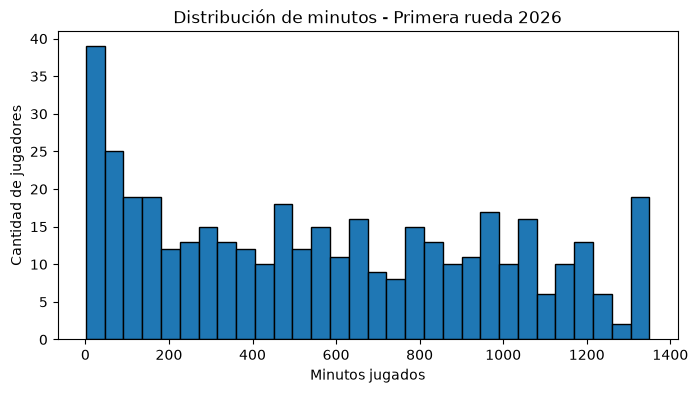

Minutos >= 0: 414 jugadores
Minutos >= 300: 279 jugadores
Minutos >= 450: 237 jugadores
Minutos >= 600: 188 jugadores
Minutos >= 675: 165 jugadores
Minutos >= 900: 111 jugadores


In [5]:
import matplotlib.pyplot as plt

# ¿Cuántos jugadores tienen rating 0? (los que Sofascore no calificó por jugar poco)
print("Jugadores con rating 0:", (df_min['rating'] == 0).sum())

# Histograma de minutos jugados: para VER cómo se reparten
plt.figure(figsize=(8,4))
plt.hist(df_min['minutesPlayed'], bins=30, edgecolor='black')
plt.xlabel('Minutos jugados')
plt.ylabel('Cantidad de jugadores')
plt.title('Distribución de minutos - Primera rueda 2026')
plt.show()

# ¿Cuántos jugadores sobreviven según distintos umbrales?
for umbral in [0, 300, 450, 600, 675, 900]:
    print(f"Minutos >= {umbral}: {(df_min['minutesPlayed'] >= umbral).sum()} jugadores")

Dado que hay muchos jugadores con pocos minutos como para hacer conclusones sobre su rendimiento a partir de su rating en Sofascore, entonces se decide filtrar a aquellos que cuenten con al menos 675 minutos. Dicho número corresponde a la mitad de los minutos totales disputados por un equipo en la primera rueda.

In [6]:
# Aplicamos el filtro elegido: al menos 675 minutos (media rueda)
UMBRAL_MINUTOS = 675
df_filtrado = df_min[df_min['minutesPlayed'] >= UMBRAL_MINUTOS].copy()

print("Jugadores tras el filtro:", len(df_filtrado))
print("Equipos representados:", df_filtrado['team'].nunique(), "de 16")
print("---")

# Chequeo: ¿cuántos jugadores quedan por equipo?
df_filtrado['team'].value_counts()

Jugadores tras el filtro: 165
Equipos representados: 16 de 16
---


team
Colo-Colo                    11
O'Higgins                    11
Unión La Calera              11
Deportes La Serena           11
Cobresal                     11
Universidad de Concepción    11
Palestino                    11
Universidad Católica         10
Universidad de Chile         10
Everton de Viña del Mar      10
Deportes Concepción          10
Huachipato                   10
Ñublense                     10
Audax Italiano               10
Coquimbo Unido                9
Deportes Limache              9
Name: count, dtype: int64

In [7]:
# 1) Rating promedio de cada equipo (solo con los jugadores filtrados)
df_filtrado['rating_promedio_equipo'] = df_filtrado.groupby('team')['rating'].transform('mean')

# 2) Métrica relativa: rating del jugador / promedio de SU equipo
df_filtrado['rating_relativo'] = df_filtrado['rating'] / df_filtrado['rating_promedio_equipo']

# 3) Diferencia en puntos de rating (más intuitiva de leer)
df_filtrado['diferencia'] = df_filtrado['rating'] - df_filtrado['rating_promedio_equipo']

# 4) Top 15 jugadores que más destacan sobre su propio equipo
df_filtrado.sort_values('rating_relativo', ascending=False).head(15)

,player,team,appearances,minutesPlayed,rating,rating_promedio_equipo,rating_relativo,diferencia
6,Francisco González,O'Higgins,15,1150,7.44,6.853636,1.085555,0.586364
11,Kevin Méndez,Unión La Calera,14,1208,7.35,6.784545,1.083344,0.565455
4,Arturo Vidal,Colo-Colo,14,1123,7.51,6.983636,1.075371,0.526364
3,Fernando Zampedri,Universidad Católica,14,1147,7.56,7.034000,1.074780,0.526000
19,Jorge Henríquez,Deportes Concepción,12,773,7.20,6.711000,1.072865,0.489000
5,Juan Cornejo,Coquimbo Unido,11,958,7.45,6.958889,1.070573,0.491111
10,Jean Meneses,Deportes Limache,15,1323,7.41,6.947778,1.066528,0.462222
7,Matías Zaldivia,Universidad de Chile,10,900,7.44,6.992000,1.064073,0.448000
8,Gabriel Castellón,Universidad de Chile,15,1350,7.44,6.992000,1.064073,0.448000
21,Jeisson Vargas,Deportes La Serena,15,1287,7.19,6.803636,1.056788,0.386364


In [ ]:
# Guardamos el dataset final
os.makedirs("data/processed", exist_ok=True)

df_final = df_filtrado.sort_values('rating_relativo', ascending=False).round(3)
df_final.to_csv("data/processed/ranking_jugadores_2026.csv", index=False)

print("Guardado:", len(df_final), "jugadores")

# De paso, miremos el otro extremo: quiénes rinden por DEBAJO de su equipo
df_final.tail(10)

Guardado: 165 jugadores


,player,team,appearances,minutesPlayed,rating,rating_promedio_equipo,rating_relativo,diferencia
78,Clemente Montes,Universidad Católica,11,700,6.75,7.034,0.960,-0.284
42,Marcelo Flores,Deportes Limache,15,1307,6.66,6.948,0.959,-0.288
49,Yahir Salazar,Deportes La Serena,12,1048,6.50,6.804,0.955,-0.304
70,Jorge Espejo,Universidad de Concepción,12,910,6.45,6.752,0.955,-0.302
50,Franco Bechtholdt,Cobresal,14,1215,6.50,6.805,0.955,-0.305
37,Javier Altamirano,Universidad de Chile,15,846,6.67,6.992,0.954,-0.322
88,Diego Carrasco,Deportes Concepción,8,690,6.39,6.711,0.952,-0.321
24,Emiliano Ramos,Everton de Viña del Mar,15,816,6.53,6.922,0.943,-0.392
87,Joaquín Gutiérrez,Deportes La Serena,14,868,6.39,6.804,0.939,-0.414
74,Alan Robledo,O'Higgins,8,709,6.43,6.854,0.938,-0.424
